In [4]:
import numpy as np
import matplotlib.pyplot as plt
import athena_mc as athenamc
from scipy.optimize import curve_fit

In [5]:
folder = "xrb_d01_s3_1e9"

In [6]:
spec = athenamc.read_spectrum(f"../{folder}/xrb.out1.spec")
print(spec.keys())

dict_keys(['dt', 'nx', 'nmu', 'nphi', 'ntot', 'nintens', 'units', 'polarized', 'yerror', 'xfaces', 'mufaces', 'phifaces', 'intensity', 'errors'])


In [7]:
imu = 0
iphi = 0

xfaces = spec['xfaces']
x = 0.5*(xfaces[1:]+xfaces[:-1])
y = spec["intensity"][0,iphi,imu,:]
yerr = spec["errors"][0,iphi,imu,:]

print(x.shape, y.shape, yerr.shape)

np.savetxt(
    "output.txt",
    np.column_stack([x, y, yerr]),
    header="x y yerr"
)

(48,) (48,) (48,)


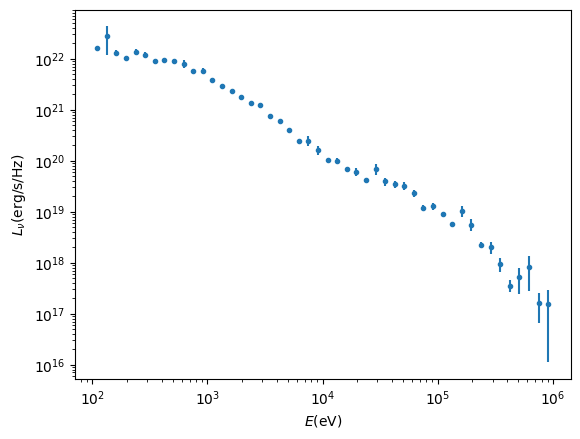

In [8]:
x, y, yerr = np.loadtxt("output.txt", unpack=True)

plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=3)

plt.xlabel(r"$E {\rm (eV)}$")
plt.ylabel(r"$L_\nu {\rm (erg/s/Hz)}$")
plt.xscale("log")
plt.yscale("log")

plt.show()

In [14]:
def power_law(x, A, alpha):
    return A * x**(-alpha)

def pow(x, y, yerr):

    popt, pcov = curve_fit(power_law, x, y, sigma=yerr, absolute_sigma=True, p0=[1e25, 2])

    A_fit, alpha_fit = popt
    A_err, alpha_err = np.sqrt(np.diag(pcov))

    print(f"A = {A_fit:.3e} ± {A_err:.3e}")
    print(f"alpha = {alpha_fit:.3f} ± {alpha_err:.3f}")

    return A_fit, A_err, alpha_fit, alpha_err

In [16]:
A_fit, A_err, alpha_fit, alpha_err = pow(x,y,yerr)

A = 4.828e+24 ± 1.702e+23
alpha = 1.160 ± 0.005


/tmp/ipykernel_2304232/740812520.py:2: RuntimeWarning: overflow encountered in power
  return A * x**(-alpha)
/tmp/ipykernel_2304232/740812520.py:2: RuntimeWarning: overflow encountered in multiply
  return A * x**(-alpha)


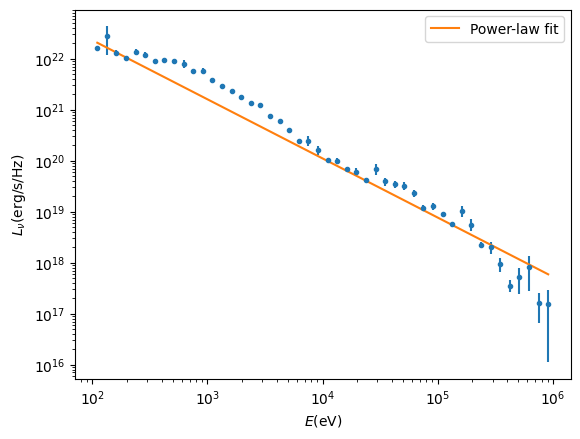

In [22]:
plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=3)

xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
plt.plot(xfit, power_law(xfit, A_fit, alpha_fit), label='Power-law fit')

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E {\rm (eV)}$")
plt.ylabel(r"$L_\nu {\rm (erg/s/Hz)}$")
plt.legend()

plt.show()